# Анализ поисковых запросов

Дескриптивный EDA по колонке `query` датасета «Самокат» (пары «запрос — товар»
с разметкой релевантности ESCI). Здесь смотрим **только на сами запросы** —
без меток релевантности, товаров и опечаток (опечатки разбираются отдельно в `../typos/`).

**Структура:**
1. Базовая статистика — сколько запросов, как они повторяются, какой они длины
2. Что ищут люди — частотный словарь и устойчивые словосочетания

In [1]:
import re

import matplotlib.pyplot as plt
import pandas as pd

DATA_PATH: str = "../DATA.csv"
TOKEN_RE: re.Pattern[str] = re.compile(r"[а-яёa-z]+")

df: pd.DataFrame = pd.read_csv(DATA_PATH)
queries: pd.Series = pd.Series(df["query"].unique(), name="query")

print(f"Строк в датасете:      {len(df):>6}")
print(f"Уникальных запросов:   {len(queries):>6}")

Строк в датасете:       79774
Уникальных запросов:     9496


## 1. Базовая статистика

### Почему запросов в 8 раз меньше, чем строк

Датасет устроен как **pairwise-разметка** (схема ESCI, как в Amazon Shopping Queries):
под каждый запрос набирается пул товаров-кандидатов из поисковой выдачи, и асессор
размечает каждую пару «запрос — товар» отдельно. Поэтому один запрос встречается
в датасете столько раз, сколько товаров под него разметили — это не дубли
и не повторные вводы пользователей.

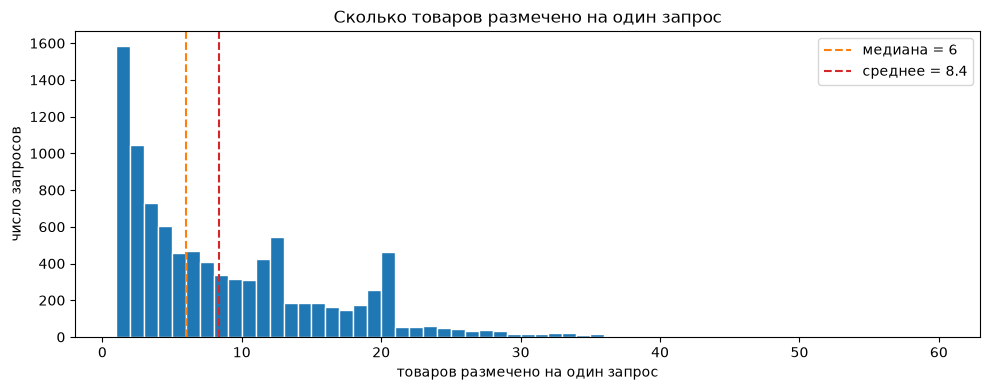

От 1 до 59 товаров на запрос, дисперсия 53.9


In [2]:
items_per_query: pd.Series = df.groupby("query").size()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(items_per_query, bins=range(1, items_per_query.max() + 2), edgecolor="white")
ax.axvline(items_per_query.median(), color="tab:orange", ls="--",
           label=f"медиана = {items_per_query.median():.0f}")
ax.axvline(items_per_query.mean(), color="tab:red", ls="--",
           label=f"среднее = {items_per_query.mean():.1f}")
ax.set_xlabel("товаров размечено на один запрос")
ax.set_ylabel("число запросов")
ax.set_title("Сколько товаров размечено на один запрос")
ax.legend()
plt.tight_layout()
plt.show()

print(f"От {items_per_query.min()} до {items_per_query.max()} товаров на запрос, "
      f"дисперсия {items_per_query.var():.1f}")

Разброс большой: чаще всего под запрос размечен **один** товар,
но у топ-10% запросов — по 20+ товаров. Горбик на 11–12 товарах намекает,
что для части запросов размечали фиксированную страницу выдачи (~12 позиций).

### Длина запросов

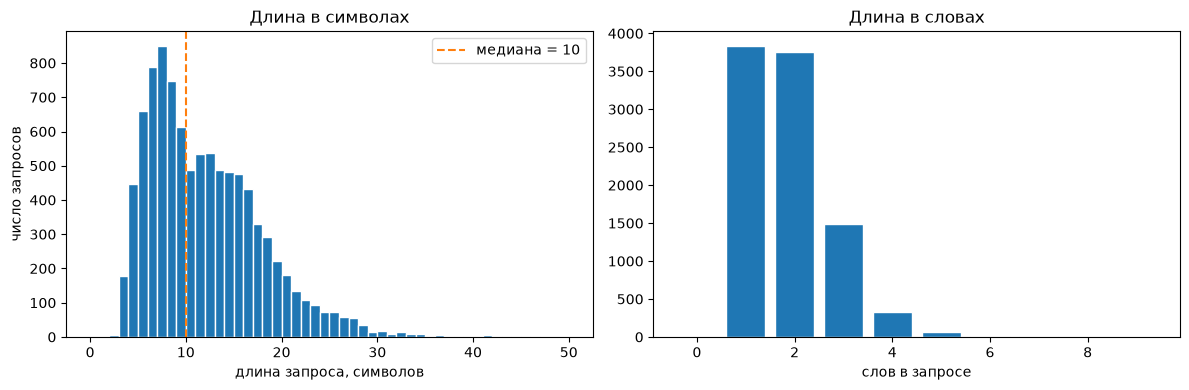

Запросы из 1–2 слов: 80%


In [3]:
char_len: pd.Series = queries.str.len()
word_cnt: pd.Series = queries.str.findall(TOKEN_RE).str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(char_len, bins=range(0, char_len.max() + 2), edgecolor="white")
axes[0].axvline(char_len.median(), color="tab:orange", ls="--",
                label=f"медиана = {char_len.median():.0f}")
axes[0].set_xlabel("длина запроса, символов")
axes[0].set_ylabel("число запросов")
axes[0].set_title("Длина в символах")
axes[0].legend()

word_dist = word_cnt.value_counts().sort_index()
axes[1].bar(word_dist.index, word_dist.values, edgecolor="white")
axes[1].set_xlabel("слов в запросе")
axes[1].set_title("Длина в словах")
plt.tight_layout()
plt.show()

share_1_2 = word_cnt.isin([1, 2]).mean()
print(f"Запросы из 1–2 слов: {share_1_2:.0%}")

Типичный запрос короткий: медиана 10 символов, 80% запросов — одно или два слова.
Это обычная картина для поиска в приложении доставки: пользователь набирает
название продукта, а не фразу.

### Крайности: самые короткие и самые длинные

In [4]:
by_len = char_len.sort_values()
shortest: pd.DataFrame = pd.DataFrame({
    "запрос": queries[by_len.index[:10]].values,
    "символов": by_len.values[:10],
})
longest: pd.DataFrame = pd.DataFrame({
    "запрос": queries[by_len.index[-10:][::-1]].values,
    "символов": by_len.values[-10:][::-1],
})
display(shortest)
display(longest)

,запрос,символов
0,де,2
1,ци,2
2,d3,2
3,фо,2
4,a4,2
5,dr,2
6,бан,3
7,юту,3
8,свр,3
9,эне,3


,запрос,символов
0,"энергетик wk up, без сахара, малина и мята 0,45 л",49
1,aravia laboratories пенка восстанавливающая с д,47
2,растворимый кофейный напиток monarch раф со вк,46
3,ароматический диффузор aroma harmony белый дуб,46
4,мороженое самокат вафельный стаканчик пломбир,45
5,фарш петелинка премиум из филе куриной грудки,45
6,ароматический спрей для текстиля перец 150 мл,45
7,стейк мираторг black angus пиканья мраморная,44
8,чипсы lay s stax нежная сметана и лук 140 г,43
9,маска майонезная шляпка для смазывания пена,43


Короткие запросы — в основном оборванные начала слов («фо», «эне», «бан»)
и коды («d3», «a4»). Самые длинные подозрительно похожи на **названия товаров
из каталога**, вставленные в поиск целиком («энергетик wk up, без сахара, малина
и мята 0,45 л») — вероятно, скопированы или введены через повторный заказ.

## 2. Что ищут люди

Считаем частоты по **уникальным запросам** (не по строкам), чтобы запросы
с большим пулом размеченных товаров не искажали картину. Служебные слова
(предлоги, союзы) из топа убираем — но не из биграмм, где они содержательны
(«без сахара», «для волос»).

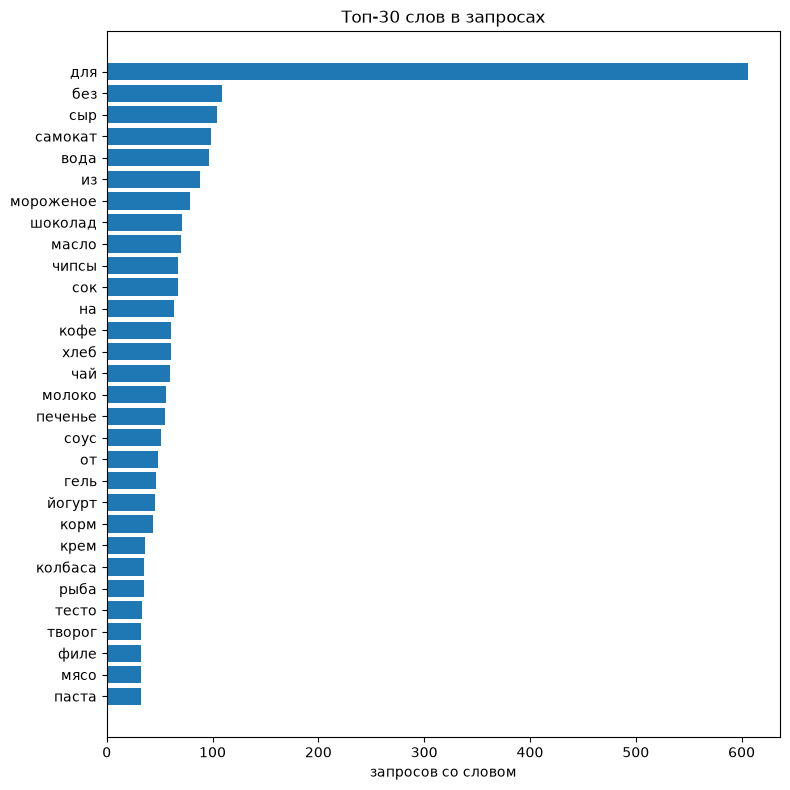

In [6]:
from collections import Counter

# STOPWORDS: frozenset[str] = frozenset(
    # "для без из на от с в и по не под до у к о".split()
# )
STOPWORDS: frozenset[str] = frozenset()
TOP_WORDS: int = 30

tokens: list[list[str]] = queries.str.findall(TOKEN_RE).tolist()
word_freq: Counter[str] = Counter(
    w for ts in tokens for w in ts if len(w) >= 2 and w not in STOPWORDS
)

top = pd.Series(dict(word_freq.most_common(TOP_WORDS)))
fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(top.index[::-1], top.values[::-1])
ax.set_xlabel("запросов со словом")
ax.set_title(f"Топ-{TOP_WORDS} слов в запросах")
plt.tight_layout()
plt.show()

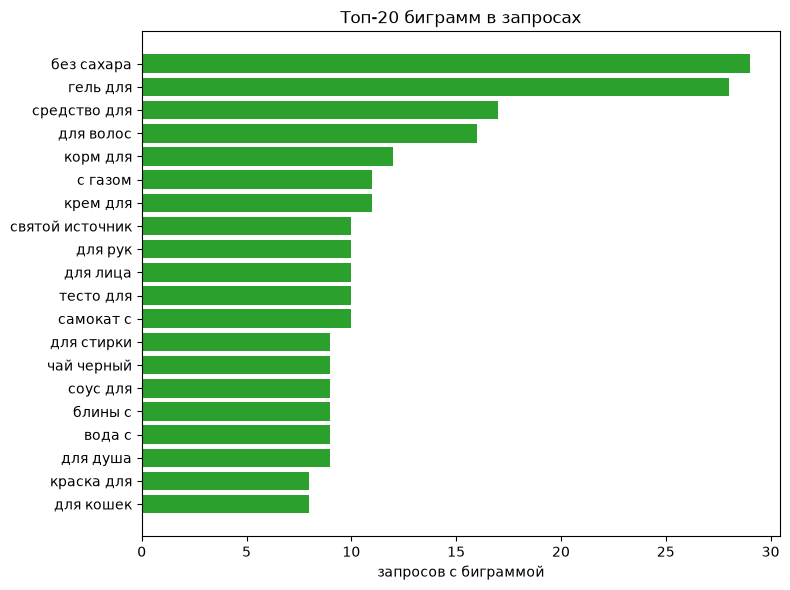

In [7]:
TOP_BIGRAMS: int = 20

bigram_freq: Counter[str] = Counter(
    " ".join(ts[i : i + 2]) for ts in tokens for i in range(len(ts) - 1)
)

top_bi = pd.Series(dict(bigram_freq.most_common(TOP_BIGRAMS)))
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_bi.index[::-1], top_bi.values[::-1], color="tab:green")
ax.set_xlabel("запросов с биграммой")
ax.set_title(f"Топ-{TOP_BIGRAMS} биграмм в запросах")
plt.tight_layout()
plt.show()

## Выводы

- **9 496 уникальных запросов** при 79 774 строках — повторы объясняются
  pairwise-разметкой (в среднем 8,4 товара на запрос, от 1 до 59), а не дублями.
- Типичный запрос — **1–2 слова, ~10 символов**: название продукта, не фраза.
- Лексика подтверждает продуктовую специфику: топ — базовая еда
  (**сыр, вода, мороженое, шоколад, масло, чипсы, сок, кофе, хлеб, чай, молоко**),
  плюс бытовая химия и уход (**гель, крем, корм**).
- Устойчивые биграммы — в основном конструкции с предлогами: **«без сахара»**
  (самая частая — заметный спрос на ЗОЖ), «гель для», «средство для», «для волос»,
  «корм для». Слово **«самокат»** в топе — пользователи ищут товары СТМ по бренду.
- Хвосты распределения длины — сырьё для дальнейшей работы: обрубки
  («фо», «эне») и вставленные целиком названия товаров.